# Pizza vs. Steak — Student Starter Notebook

**Goal:** Build a binary image classifier (**pizza** vs **steak**) using only images from `pizza_steak/train/`.

**Your tasks**
1. **Implement your model** inside `build_model()` — input images are provided by the fixed pipeline.
2. **Compile and train** your model on the provided `train_ds` and `val_ds`.
3. **Export** your final model as `student_model.keras` and create a model diagram image (e.g., `student_model.png`).

**Rules**
- Do **not** modify the fixed cells (data loading/split/pipeline).
- You may use transfer learning (e.g., `tf.keras.applications`).
- Ensure your model outputs a value suitable for **binary classification** and is **compiled** before training.

## 0. Imports (fixed)

In [33]:
import tensorflow as tf
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


## 1. Data paths (fixed)

In [34]:
DATA_ROOT = Path('pizza_steak')
TRAIN_DIR = DATA_ROOT / 'train'

classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
assert set(classes) == {'pizza', 'steak'}, f"Expected classes ['pizza','steak'], got: {classes}"
print('Classes:', classes)

Classes: ['pizza', 'steak']


## 2. File listing + split (fixed)

In [35]:
paths, labels = [], []

for cls in classes:
    for p in (TRAIN_DIR / cls).glob('*.jpg'):
        paths.append(str(p))
        labels.append(cls)

assert len(paths) > 0, 'No training images found.'

df = pd.DataFrame({'path': paths, 'label': labels})
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=SEED
)
print('Train size:', len(train_df), 'Val size:', len(val_df))



Train size: 1200 Val size: 300


## 3. tf.data pipelines (fixed)

> **Augmentation:** Applied once in the **`tf.data`** pipeline below (training dataset only). Please **do not** add extra augmentation layers inside your model.

In [36]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
label_to_idx = {c: i for i, c in enumerate(classes)}

@tf.function
def _decode_img(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, tf.cast(label, tf.int32)

@tf.function
def _augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label

def make_ds(df, training=False):
    paths = df['path'].values
    labels = df['label'].map(label_to_idx).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_decode_img, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df, training=True)
val_ds   = make_ds(val_df, training=False)

for imgs, ys in train_ds.take(1):
    print('Sample batch:', imgs.shape, ys.shape)

Sample batch: (32, 224, 224, 3) (32,)


### Optional: preview one image and its label

Run the cell below to display a **random example** from the **validation** dataset (no augmentation).

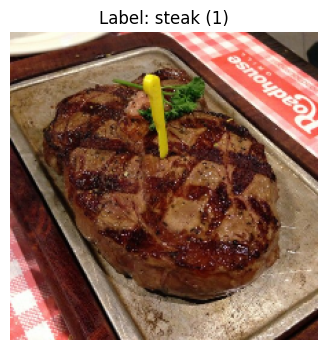

In [37]:
# Shows one random image + label from the *validation* dataset (no augmentation).
import numpy as np
import matplotlib.pyplot as plt

label_to_name = {v: k for k, v in label_to_idx.items()}

# Take one batch from validation, pick a random index
imgs, ys = next(iter(val_ds))
i = np.random.randint(len(ys))
img = imgs[i].numpy()
label_int = int(ys[i].numpy())

plt.figure(figsize=(4, 4))
plt.imshow(img)  # already in [0,1]
plt.axis('off')
plt.title(f"Label: {label_to_name[label_int]} ({label_int})")
plt.show()

## 4. Build your model (EDIT THIS CODE BLOCK)

- Return a **compiled** model.
- **Input images** come as `(224, 224, 3)` tensors from the pipeline.
- Use any compatible architecture; ensure the output suits **binary classification**.

In [38]:
# def preprocess_image(image, label):
    
#     image = tf.image.rgb_to_grayscale(image)
    
#     image = tf.image.resize(image, [28, 28])
    
#     image = image / 255.0
#     return image, label


# train_ds = train_ds.map(preprocess_image)
# val_ds = val_ds.map(preprocess_image)

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),

        tf.keras.layers.Conv2D(4,3, activation="relu"),
        tf.keras.layers.BatchNormalization(), 
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.6),
        # tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        
        # loss="sparse_categorical_crossentropy", 
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        )

    reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        callbacks=[early_stop,reduce_lr],
        verbose=1
    )


    loss, acc = model.evaluate(val_ds)
    print(f"Final Accuracy: {acc*100:.2f}%")
    tot_parms = model.count_params()
    print("Total parameter is: ", tot_parms)
    return model




model = build_model()
model.summary()

# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=4,
#     restore_best_weights=True
# )


# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=10,
#     callbacks=[early_stop],
#     verbose=1
# )


# loss, acc = model.evaluate(val_ds)
# print(f"Final Accuracy: {acc*100:.2f}%")


model.save("student_model.keras")
tf.keras.utils.plot_model(model, to_file="student_model.png", show_shapes=True)

Epoch 1/5


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'conv2d_11' is incompatible with the layer: expected axis -1 of input shape to have value 1, but received input with shape (None, 224, 224, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 224, 224, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [40]:
# def preprocess_image(image, label):
    
#     image = tf.image.rgb_to_grayscale(image)
    
#     image = tf.image.resize(image, [28, 28])
    
#     image = image / 255.0
#     return image, label


# train_ds = train_ds.map(preprocess_image)
# val_ds = val_ds.map(preprocess_image)

In [41]:
# def build_model():
#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=(224, 224, 3)),

#         tf.keras.layers.Conv2D(5,3, activation="relu"),
#         tf.keras.layers.BatchNormalization(), 
#         tf.keras.layers.MaxPool2D(),
#         tf.keras.layers.Dropout(0.6),
#         tf.keras.layers.GlobalAveragePooling2D(),
#         tf.keras.layers.Dropout(0.5),
#         tf.keras.layers.Dense(1, activation="sigmoid")
#     ])
    
#     model.compile(
#         loss="binary_crossentropy",
#         optimizer="adam",
#         metrics=["accuracy"]
#     )

    
# #     early_stop = tf.keras.callbacks.EarlyStopping(
# #             monitor="val_loss",
# #             patience=4,
# #             restore_best_weights=True
# #         )

# #     reduce_lr = ReduceLROnPlateau(
# #     monitor="val_loss",
# #     factor=0.5,
# #     patience=2,
# #     min_lr=1e-5
# # )

#     history = model.fit(
#         train_ds,
#         validation_data=val_ds,
#         epochs=15,
#         # callbacks=[early_stop,reduce_lr],
#         verbose=1
#     )


#     loss, acc = model.evaluate(val_ds)
#     print(f"Final Accuracy: {acc*100:.2f}%")
#     tot_parms = model.count_params()
#     print("Total parameter is: ", tot_parms)
#     return model
   

# model = build_model()
# model.summary()

In [42]:
# import tensorflow as tf
# # from tensorflow.keras.callbacks import EarlyStopping
# # def build_model():
# #     return model

# # model = build_model()

# # model.summary()

# model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=(28,28, 1)),
#         tf.keras.layers.Conv2D(filters=8, kernel_size=5, activation="relu"), 
#         tf.keras.layers.MaxPool2D(pool_size=2),
#         tf.keras.layers.Flatten(),
#         tf.keras.layers.Dense(128, activation="relu"),
#         tf.keras.layers.Dense(128, activation="relu"),
#         tf.keras.layers.Dropout(0.5),
#         tf.keras.layers.Dense(10, activation="softmax")
#     ])
    
# model.compile(
#         loss="sparse_categorical_crossentropy",
#         # loss="binary_crossentropy", # As a binary, can we use this??
#         optimizer="adam",
#         metrics=["accuracy"]
#     )
    
# history = model.fit(train_ds,validation_data=val_ds,epochs=10,verbose=1)
# # loss, acc = model.evaluate(val_ds)
# # print("final acc:")

# # save model
# # model.save("student_model.keras")
# # tf.keras.utils.plot_model(
# #     model,
# #     to_file="student_model.png",
# #     show_shapes=True

# # print(train_ds)

# # import matplotlib.pyplot as plt
# # from tensorflow.keras.callbacks import EarlyStopping

# # early_stop = EarlyStopping(
# #     monitor="val_loss",
# #     patience=4,
# #     restore_best_weights=True



In [43]:
# print(train_ds)

## 5. Train, evaluate and export (CREATE NEW CODE BLOCK(S))

**You must:**
- Fit your model on `train_ds` and validate on `val_ds`.
- Save model (e.g. `student_model.keras`).
- Save a model diagram image (e.g. `student_model.png`).

In [44]:

# # 3) FIT
# import matplotlib.pyplot as plt
# # from tensorflow.keras.callbacks import EarlyStopping

# # early_stop = EarlyStopping(
# #     monitor="val_loss",
# #     patience=4,
# #     restore_best_weights=True

# history = model.fit(train_ds,validation_data=val_ds,epochs=10,verbose=1)

In [45]:
# model.save("student_model.keras")
# tf.keras.utils.plot_model(
#     model,
#     to_file="student_model.png",
#     show_shapes=True
# )